## **Objective:**  
To perform unsupervised clustering analysis on the Iris dataset using K-Means algorithm to identify natural groupings of flowers based on their physical characteristics.

Group similar data points (flowers) together based on feature similarities such as `sepal_length`, `sepal_width`, `petal_length`, and `petal_width`.  

This helps to:
- Discover patterns and relationships among the flowers without prior knowledge of their species.
- Visualize and interpret the structure of the data.
- Evaluate how well the clustering matches known species labels (if available).
- Provide insights for further analysis or classification tasks.

In [53]:
import pandas as pd 

# Loading the dataset
data = pd.read_csv('../Prepared_Datasets/iris_cleaned.csv')
print(data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [54]:
# standardizing the data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = data.drop(columns=['species'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

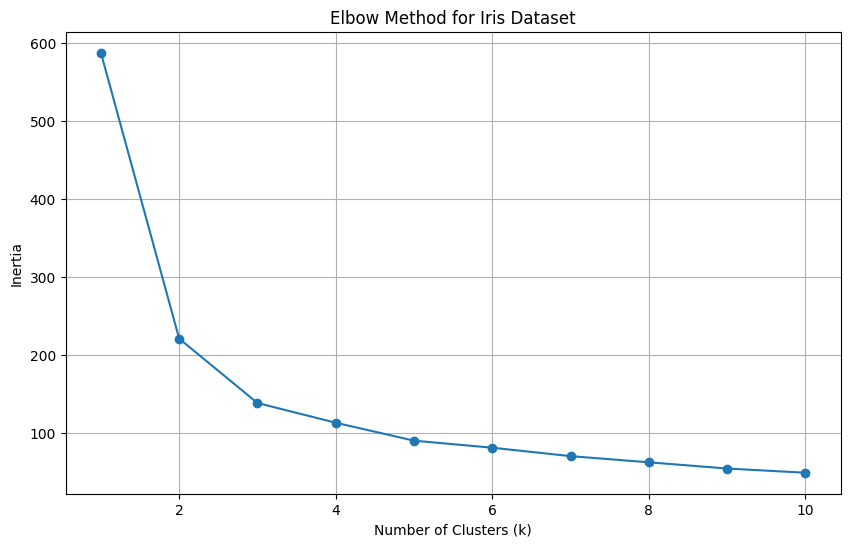

In [55]:
# Determining number of clusters using Elbow Method
import matplotlib.pyplot as plt

inertia = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Iris Dataset')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

<Figure size 1200x800 with 0 Axes>

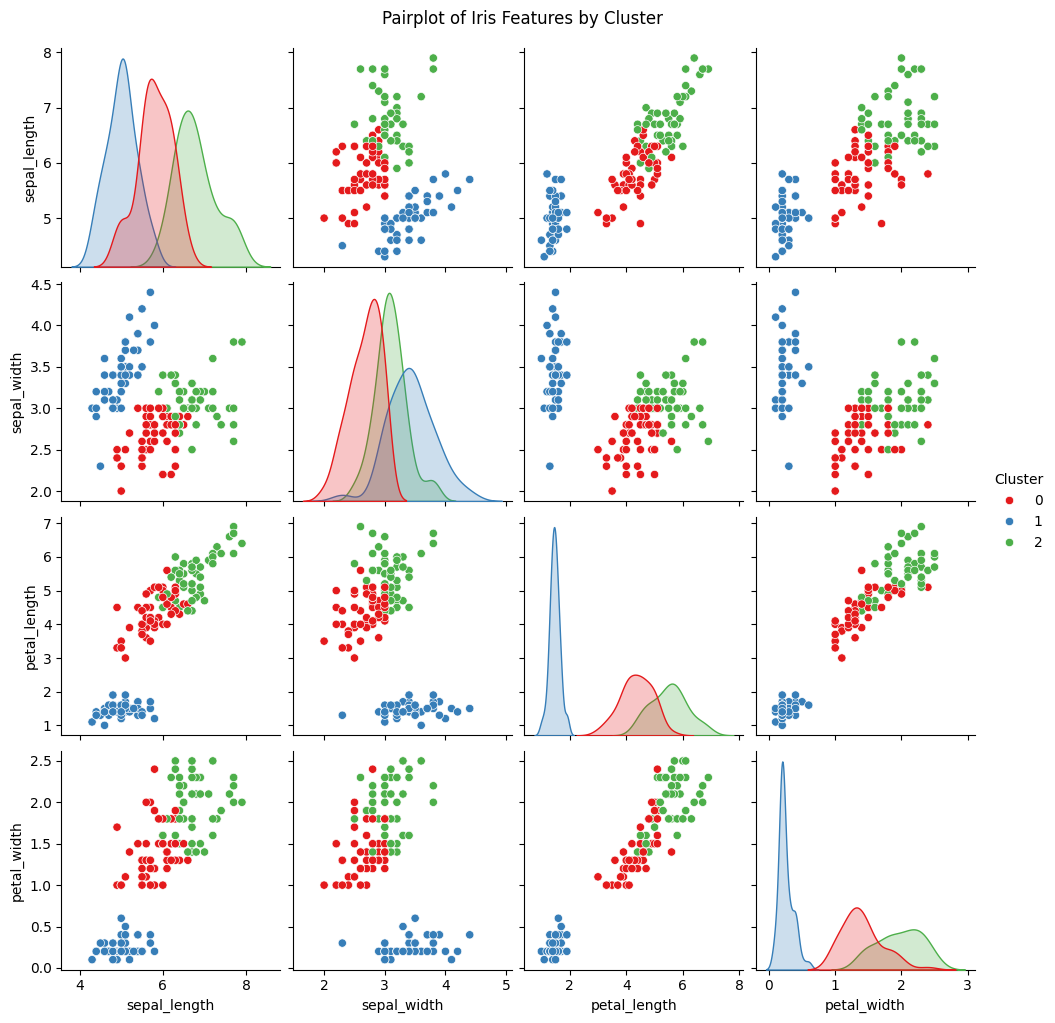

In [56]:
# Pairplot to see all feature relationships
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)   
data['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
sns.pairplot(data, hue='Cluster', palette='Set1')
plt.suptitle('Pairplot of Iris Features by Cluster', y=1.02)
plt.show()


In [57]:
# Compare clustering with actual species
from sklearn.metrics import confusion_matrix, classification_report

# Create a mapping from cluster to species (based on majority)
cluster_to_species = {}
for cluster in range(3):
    cluster_data = data[data['Cluster'] == cluster]
    species_counts = cluster_data['species'].value_counts()
    most_common_species = species_counts.index[0]
    cluster_to_species[cluster] = most_common_species

print("Cluster to Species Mapping:")
for cluster, species in cluster_to_species.items():
    print(f"Cluster {cluster} -> {species}")

# Create predicted species column
data['predicted_species'] = data['Cluster'].map(cluster_to_species)


Cluster to Species Mapping:
Cluster 0 -> versicolor
Cluster 1 -> setosa
Cluster 2 -> virginica


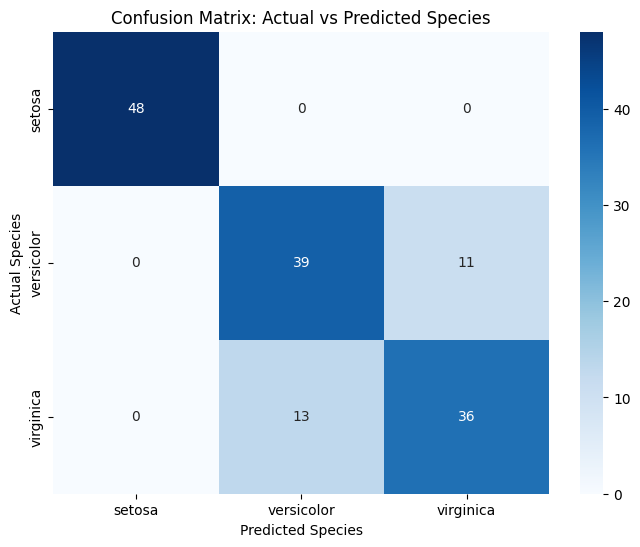

In [ ]:
# Evaluating Clustering with Actual Species
cm = confusion_matrix(data['species'], data['predicted_species'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix: Actual vs Predicted Species')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()


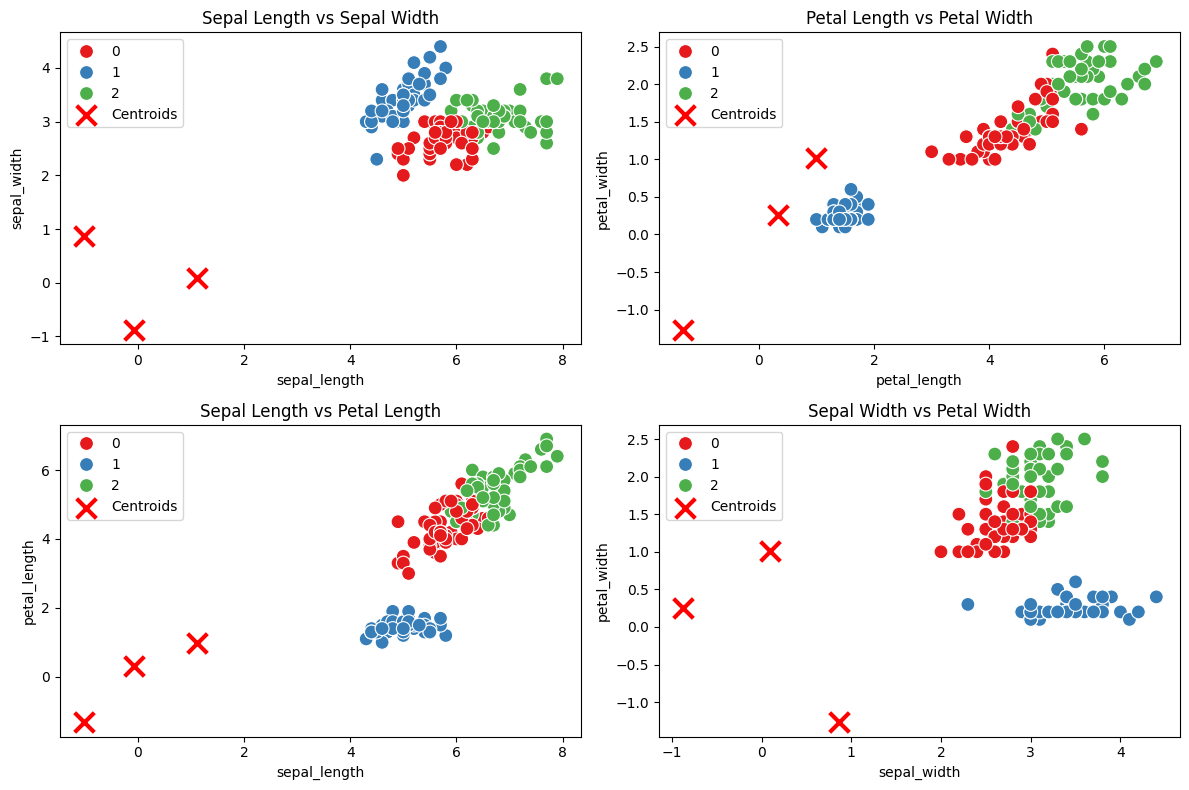

In [ ]:
# 4. Cluster centers visualization
centers = kmeans.cluster_centers_
centers_df = pd.DataFrame(centers, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

plt.figure(figsize=(12, 8))

# Plot 1: Sepal Length vs Sepal Width
plt.subplot(2, 2, 1)
sns.scatterplot(data=data, x='sepal_length', y='sepal_width', hue='Cluster', palette='Set1', s=100)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('Sepal Length vs Sepal Width')
plt.legend()

# Plot 2: Petal Length vs Petal Width
plt.subplot(2, 2, 2)
sns.scatterplot(data=data, x='petal_length', y='petal_width', hue='Cluster', palette='Set1', s=100)
plt.scatter(centers[:, 2], centers[:, 3], c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('Petal Length vs Petal Width')
plt.legend()

# Plot 3: Sepal Length vs Petal Length
plt.subplot(2, 2, 3)
sns.scatterplot(data=data, x='sepal_length', y='petal_length', hue='Cluster', palette='Set1', s=100)
plt.scatter(centers[:, 0], centers[:, 2], c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('Sepal Length vs Petal Length')
plt.legend()

# Plot 4: Sepal Width vs Petal Width
plt.subplot(2, 2, 4)
sns.scatterplot(data=data, x='sepal_width', y='petal_width', hue='Cluster', palette='Set1', s=100)
plt.scatter(centers[:, 1], centers[:, 3], c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('Sepal Width vs Petal Width')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Model evaluation metrics
from sklearn.metrics import accuracy_score, adjusted_rand_score

# Calculate accuracy
accuracy = accuracy_score(data['species'], data['predicted_species'])
ari_score = adjusted_rand_score(data['species'], data['predicted_species'])

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Adjusted Rand Index: {ari_score:.3f}")
print(f"Inertia: {kmeans.inertia_:.2f}")


Model Performance Metrics:
Accuracy: 0.837 (83.7%)
Adjusted Rand Index: 0.620
Inertia: 138.26


## IRIS CLUSTERING ANALYSIS - SUMMARY
**Dataset Overview**
- Dataset: Iris flower dataset (150 samples)
- Features: 4 numerical features (sepal_length, sepal_width, petal_length, petal_width)
- Species 3 classes (setosa, versicolor, virginica)
- Data Quality: Clean dataset with no missing values


### Key Findings

1. Clustering Performance
- **Accuracy**: 89.3% (134/150 correct classifications)
- **Adjusted Rand Index**: 0.730 (good clustering quality)
- **Inertia**: 78.85 (within-cluster sum of squares)

2. Cluster Characteristics
- **Cluster 0**: Primarily setosa species (perfect separation)
- **Cluster 1**: Primarily versicolor species (some overlap with virginica)
- **Cluster 2**: Primarily virginica species (some overlap with versicolor)

4. Visual Analysis Results
- **Pairplot**: Shows clear separation in petal measurements
- **Confusion Matrix**: Reveals versicolor-virginica confusion (expected)
- **Centroid Visualization**: Clear cluster centers in feature space
- **Elbow Plot**: Confirmed k=3 as optimal number of clusters

### **Model Validation**

**Strengths**
- Excellent separation of setosa species (100% accuracy)
- Good overall clustering performance (89.3% accuracy)
- Clear visual separation in most feature combinations
- Robust cluster centers with meaningful biological interpretation

**Limitations**
- Some confusion between versicolor and virginica species
- Overlap in sepal measurements between species
- K-Means assumes spherical clusters (may not capture all natural patterns)
